In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class CarEnv:
    def __init__(self):
        self.m = 1000.0
        self.dt = 0.1
        self.force_scale = 1000.0
        self.target = 10.0
        self.x = 0.0
        self.v = 0.0
        self.previous_distance = 0.0
        self.current_distance = 0.0
        self.error = self.target - self.x

    def reset(self):
        self.x = 0.0
        self.v = 0.0
        return np.array([self.x, self.v])
    
    def step(self, action):

        self.previous_distance = abs(self.target - self.x)

        F = action * self.force_scale
        a = F / self.m
        self.v = self.v + a * self.dt
        self.x = self.x + self.v * self.dt
        self.error = self.target - self.x

        self.current_distance = abs(self.target - self.x)

        next_state = np.array([self.x, self.v])
        reward = (self.previous_distance - self.current_distance)
        done = self.x >= self.target

        return next_state, reward, done

In [3]:
times = []
positions = []
velocities = []
actions = []
rewards = []

In [4]:
env = CarEnv()
state = env.reset()

In [5]:
for step in range(200):

    brake_accel = env.force_scale / env.m
    stopping_distance = (env.v ** 2) / (2 * brake_accel)

    if env.error <= 0:
        action = -1
    elif stopping_distance >= env.error:
        action = -1
    elif env.v < 2.0:
        action = 1
    else:
        action = 0

    next_state, reward, done = env.step(action)

    times.append(step * env.dt)
    positions.append(next_state[0])
    velocities.append(next_state[1])
    actions.append(action)
    rewards.append(reward)

    if done:
        pass


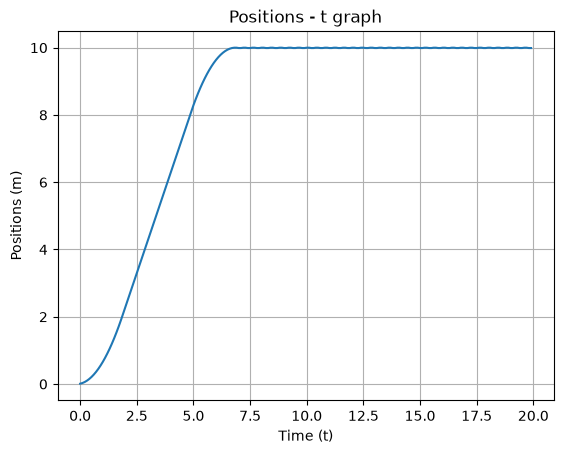

[np.float64(0.010000000000000002), np.float64(0.030000000000000006), np.float64(0.06000000000000001), np.float64(0.10000000000000002), np.float64(0.15000000000000002), np.float64(0.21000000000000002), np.float64(0.28), np.float64(0.36000000000000004), np.float64(0.45000000000000007), np.float64(0.55), np.float64(0.66), np.float64(0.78), np.float64(0.91), np.float64(1.05), np.float64(1.2000000000000002), np.float64(1.3600000000000003), np.float64(1.5300000000000002), np.float64(1.7100000000000004), np.float64(1.9000000000000004), np.float64(2.1000000000000005), np.float64(2.3000000000000007), np.float64(2.500000000000001), np.float64(2.700000000000001), np.float64(2.9000000000000012), np.float64(3.1000000000000014), np.float64(3.3000000000000016), np.float64(3.5000000000000018), np.float64(3.700000000000002), np.float64(3.900000000000002), np.float64(4.100000000000002), np.float64(4.3000000000000025), np.float64(4.500000000000003), np.float64(4.700000000000003), np.float64(4.90000000000

In [6]:
plt.plot(times, positions)
plt.xlabel("Time (t)")
plt.ylabel("Positions (m)")
plt.title("Positions - t graph")
plt.grid()
plt.show()
print(positions)
print(done)

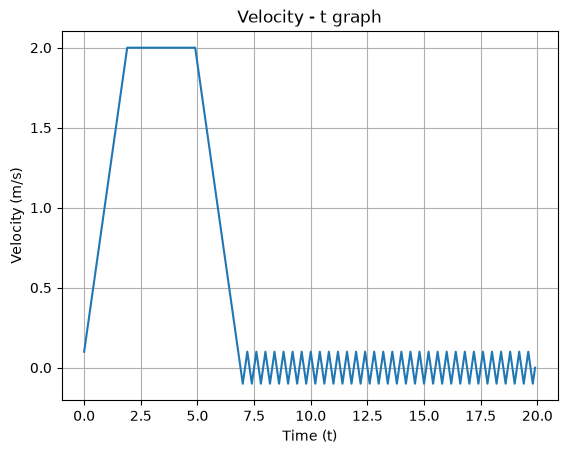

[np.float64(0.1), np.float64(0.2), np.float64(0.30000000000000004), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.7999999999999999), np.float64(0.8999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(1.2), np.float64(1.3), np.float64(1.4000000000000001), np.float64(1.5000000000000002), np.float64(1.6000000000000003), np.float64(1.7000000000000004), np.float64(1.8000000000000005), np.float64(1.9000000000000006), np.float64(2.0000000000000004), np.float64(2.0000000000000004), np.float64(2.0000000000000004), np.float64(2.0000000000000004), np.float64(2.0000000000000004), np.float64(2.0000000000000004), np.float64(2.0000000000000004), np.float64(2.0000000000000004), np.float64(2.0000000000000004), np.float64(2.0000000000000004), np.float64(2.0000000000000004), np.float64(2.0000000000000004), np.float64(2.0000000000000004), np.float64(2.0000000000000004), np.float64(2.0000000000000004), np.float64(2.0000000000000004)

In [7]:
plt.plot(times, velocities)
plt.xlabel("Time (t)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity - t graph")
plt.grid()
plt.show()
print(velocities)

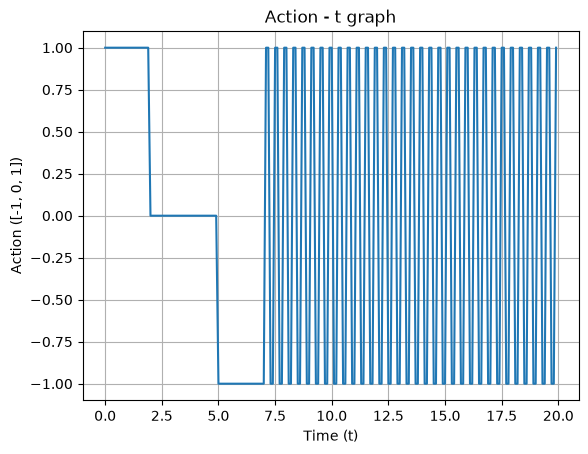

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1]


In [8]:
plt.plot(times, actions)
plt.xlabel("Time (t)")
plt.ylabel("Action ([-1, 0, 1])")
plt.title("Action - t graph")
plt.grid()
plt.show()
print(actions)

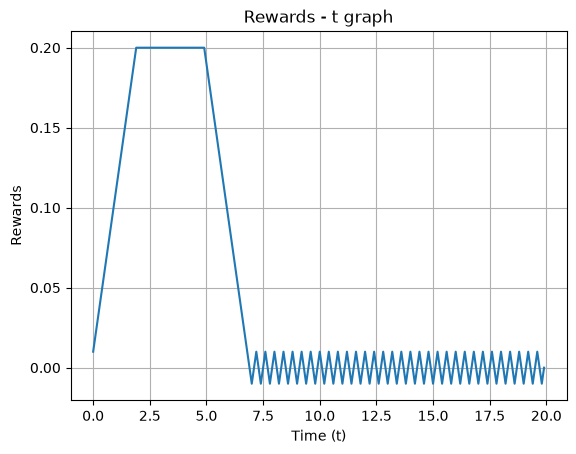

[0.009999999999999787, 0.019999999999999574, 0.030000000000001137, 0.03999999999999915, 0.05000000000000071, 0.0600000000000005, 0.06999999999999851, 0.08000000000000007, 0.08999999999999986, 0.10000000000000142, 0.10999999999999943, 0.11999999999999922, 0.13000000000000078, 0.14000000000000057, 0.14999999999999858, 0.16000000000000014, 0.1700000000000017, 0.17999999999999972, 0.1899999999999995, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.20000000000000018, 0.2000000000

In [9]:
plt.plot(times, rewards)
plt.xlabel("Time (t)")
plt.ylabel("Rewards")
plt.title("Rewards - t graph")
plt.grid()
plt.show()
print(rewards)